In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, accuracy_score,  recall_score, f1_score


In [76]:
# set display options for pandas and seaborn
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)
sns.set_theme(style="darkgrid")

csv_file_path = "../dataset/diabetes.csv"

In [77]:
df = pd.read_csv(csv_file_path)
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0            6      148             72             35        0 33.600   
1            1       85             66             29        0 26.600   
2            8      183             64              0        0 23.300   
3            1       89             66             23       94 28.100   
4            0      137             40             35      168 43.100   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [78]:
df.shape

(768, 9)

In [79]:
#EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [80]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [81]:
# quick check encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(5))

Pregnancies
1    135
0    111
2    103
3     75
4     68
Name: count, dtype: int64
Glucose
99     17
100    17
111    14
125    14
129    14
Name: count, dtype: int64
BloodPressure
70    57
74    52
78    45
68    45
72    44
Name: count, dtype: int64
SkinThickness
0     227
32     31
30     27
27     23
23     22
Name: count, dtype: int64
Insulin
0      374
105     11
130      9
140      9
120      8
Name: count, dtype: int64
BMI
32.000    13
31.600    12
31.200    12
0.000     11
32.400    10
Name: count, dtype: int64
DiabetesPedigreeFunction
0.258    6
0.254    6
0.207    5
0.261    5
0.259    5
Name: count, dtype: int64
Age
22    72
21    63
25    48
24    46
23    38
Name: count, dtype: int64
Outcome
0    500
1    268
Name: count, dtype: int64


In [82]:
# identify columns with zero values that may represent missing data
zero_summary =(
    df.eq(0).sum().to_frame(name='zero_count').assign(zero_percentage=lambda x: (x['zero_count'] / len(df)) * 100)
)

print(zero_summary)

                          zero_count  zero_percentage
Pregnancies                      111           14.453
Glucose                            5            0.651
BloodPressure                     35            4.557
SkinThickness                    227           29.557
Insulin                          374           48.698
BMI                               11            1.432
DiabetesPedigreeFunction           0            0.000
Age                                0            0.000
Outcome                          500           65.104


In [83]:
# in this dataset glucose,bp,skin thickness,insulin and bmi have zero values which are not possible in real life scenario. So we will treat them as missing values and replace them with median of the respective columns.

In [84]:
df.duplicated().sum()

np.int64(0)

In [85]:
#print value counts for the target variable
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [86]:
n_diabetes = (df['Outcome']==1).sum()
n_no_diabetes = (df['Outcome']==0).sum()
print(f"Number of diabetes cases: {n_diabetes}")
print(f"Number of non-diabetes cases: {n_no_diabetes}")
print ("\n Imbalance ratio: {:.2f}".format(n_no_diabetes / n_diabetes))

Number of diabetes cases: 268
Number of non-diabetes cases: 500

 Imbalance ratio: 1.87


In [87]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose,768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
BloodPressure,768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
SkinThickness,768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin,768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000
BMI,768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


In [88]:
#Data Visualization

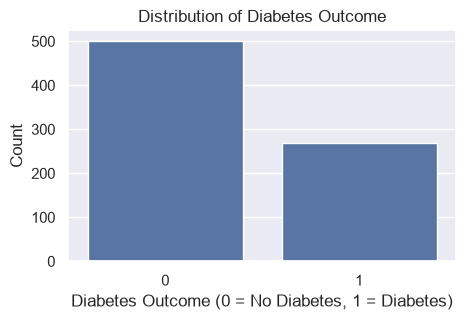

In [89]:
#countplot for target variable
plt.figure(figsize=(5,3))
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.show()


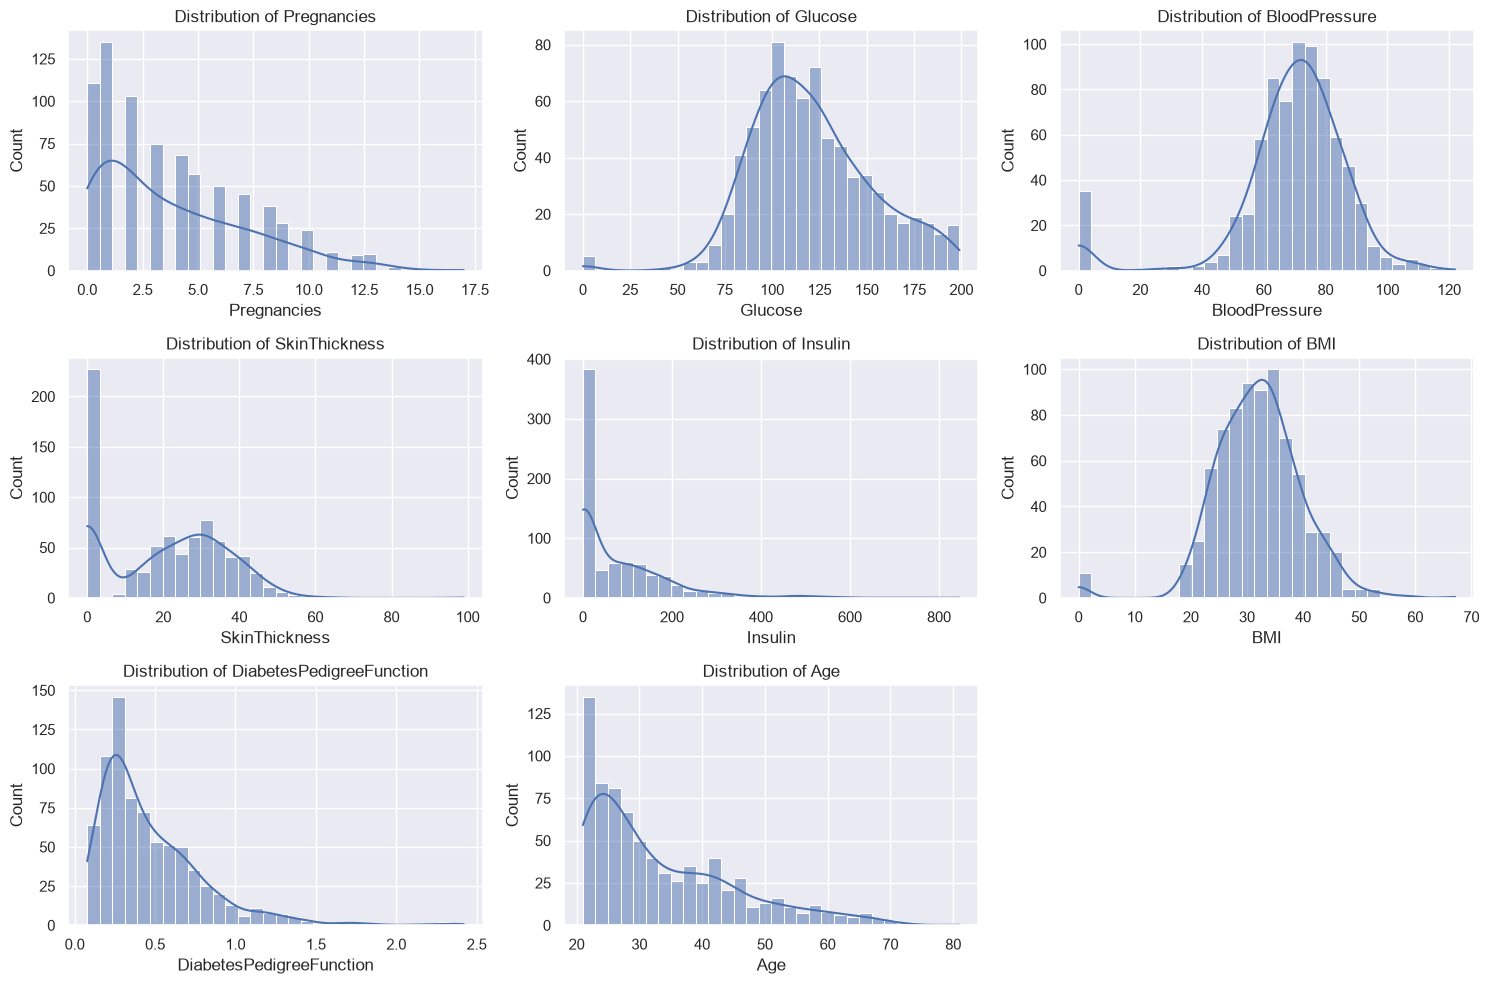

In [90]:
#create histograms for numerical features
plt.figure(figsize=(15, 10))
numerical_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()


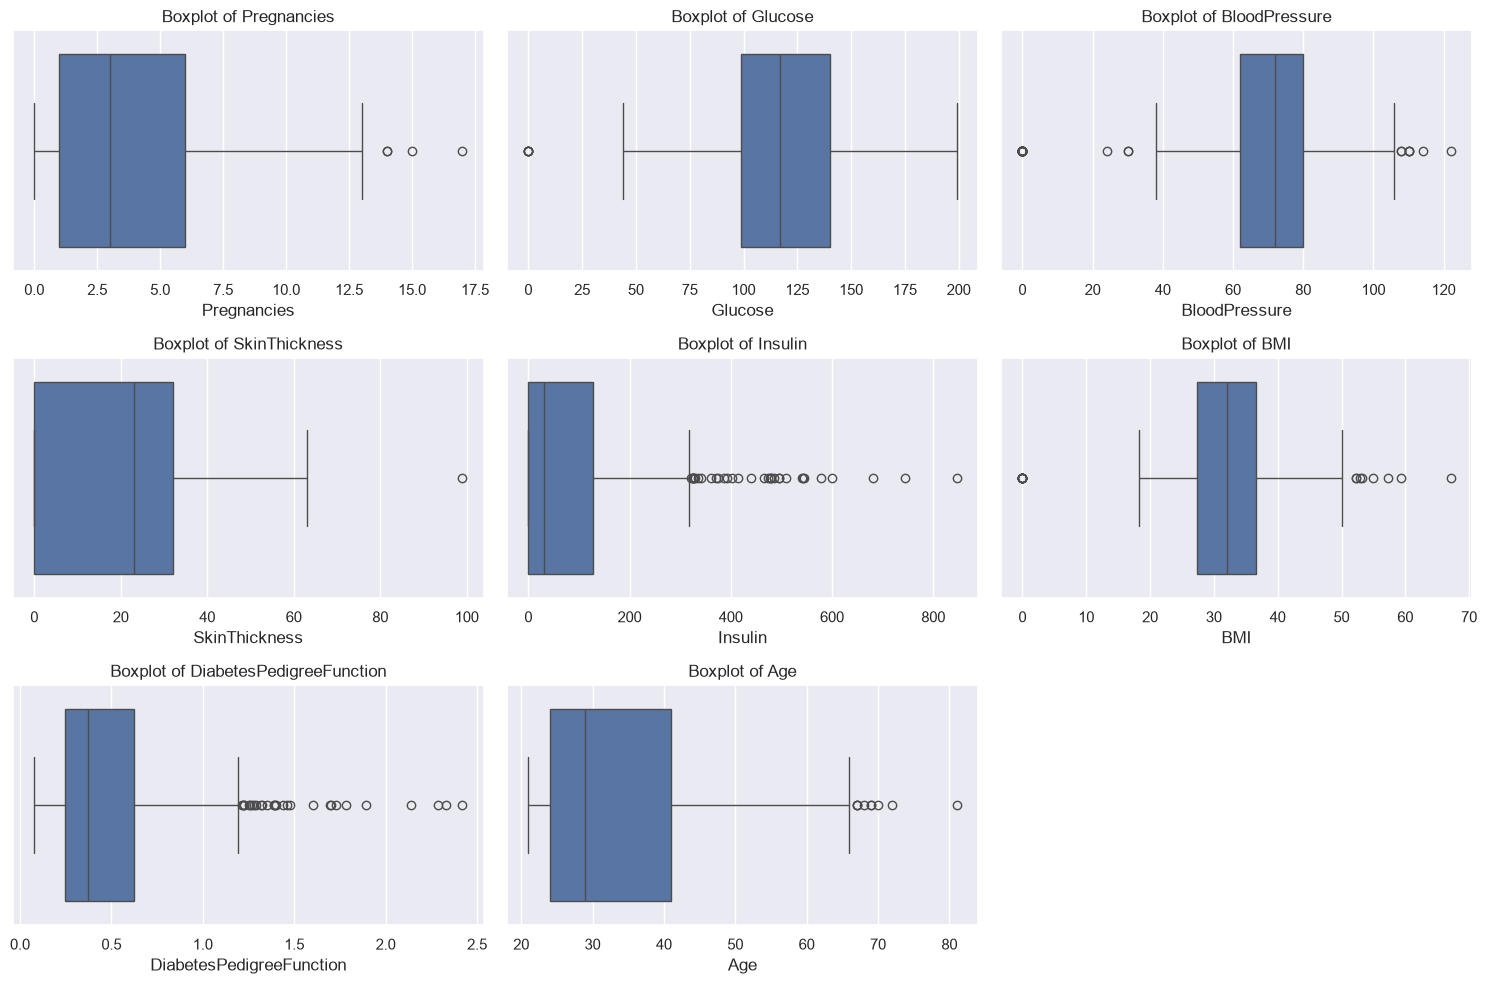

In [91]:
# outlier detection using boxplots
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

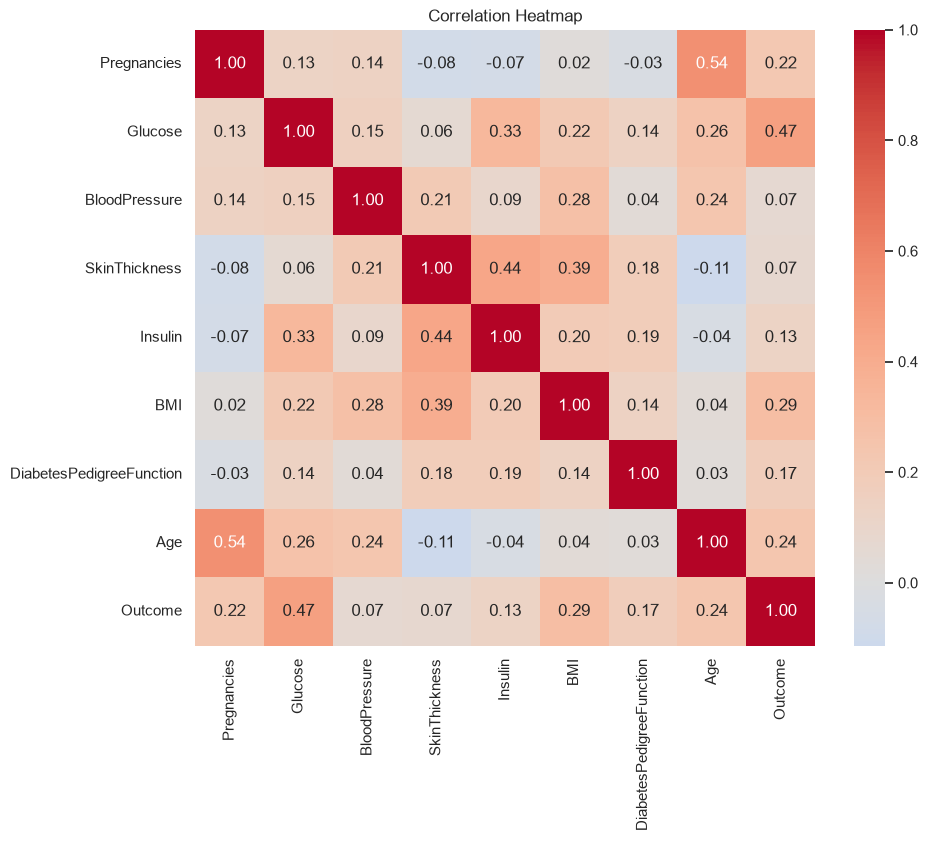

In [92]:
#heat map for correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Heatmap')
plt.show()



In [93]:
# data preprocessing

In [94]:
x= df.drop('Outcome', axis=1)
y = df['Outcome']

In [95]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [96]:
print(f"Training set shape: {x_train.shape}, {y_train.shape}")
print(f"Testing set shape: {x_test.shape}, {y_test.shape}")


Training set shape: (614, 8), (614,)
Testing set shape: (154, 8), (154,)


In [97]:
# 0=> NAN for selected columns : NAN => median imputation for selected columns
zero_as_missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

numerical_features=x_train.select_dtypes(include=[np.number]).columns.tolist()

def replace_zero_with_nan(X,cols):

    """
    replase 0 => NAN for selected columns in pandas dataframe
    returns a new dataframe (safe for sklearn pipelines)
    """
    X_copy = X.copy()
    for col in cols:
        if col in X_copy.columns:
            X_copy[col] = X_copy[col].replace(0, np.nan)
    return X_copy

zero_to_nan_transformer = FunctionTransformer(
    replace_zero_with_nan,
    kw_args={'cols': zero_as_missing_cols},
    validate=False)

numerical_transformer = Pipeline(steps=[
    ('zero_to_nan', zero_to_nan_transformer),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features)
])

In [98]:
#baseline model - logistic regression
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])


In [99]:
#train the baseline model
baseline_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [100]:
def evaluate_model(model, x_train, y_train, x_test, y_test):
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    print("Training Classification Report:")
    print(classification_report(y_train, y_train_pred))
    
    print("Testing Classification Report:")
    print(classification_report(y_test, y_test_pred))
    
    print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    
    print(f"Training Recall: {recall_score(y_train, y_train_pred):.4f}")
    print(f"Testing Recall: {recall_score(y_test, y_test_pred):.4f}")
    
    print(f"Training F1 Score: {f1_score(y_train, y_train_pred):.4f}")
    print(f"Testing F1 Score: {f1_score(y_test, y_test_pred):.4f}")

In [101]:
evaluate_model(baseline_pipeline, x_train, y_train, x_test, y_test)

Training Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       400
           1       0.77      0.59      0.67       214

    accuracy                           0.80       614
   macro avg       0.79      0.75      0.76       614
weighted avg       0.79      0.80      0.79       614

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

Training Accuracy: 0.7964
Testing Accuracy: 0.7078
Training Recall: 0.5935
Testing Recall: 0.5000
Training F1 Score: 0.6702
Testing F1 Score: 0.5455


In [102]:
neg=(y_train==0).sum()
pos=(y_train==1).sum()
scale_pos_weight = neg / pos

print(f"Number of negative samples: {neg}")
print(f"Number of positive samples: {pos}")
print(f"Scale pos weight: {scale_pos_weight:.2f}")

Number of negative samples: 400
Number of positive samples: 214
Scale pos weight: 1.87


In [103]:
#models to try: Logistic Regression, SVM, Random Forest, XGBoost

models = {
    "LogisticRegression":Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, class_weight='balanced',max_iter=1000))
    ]),
    
    "SVC":Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', SVC(random_state=42, class_weight='balanced'))
    ]),
    
    "RandomForest":Pipeline(
        steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
        ]),
    "XGBClassifier":Pipeline(
        steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss'))
        ])
        
    

}

In [104]:
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)   

In [105]:
for model_name, model_pipeline in models.items():
    recall_scores = []
    f1_scores = []

    for train_index, val_index in cv.split(x_train, y_train):
        x_train_fold, x_val_fold = x_train.iloc[train_index], x_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        
        model_pipeline.fit(x_train_fold, y_train_fold)
        predictions = model_pipeline.predict(x_val_fold)
        
        recall_scores.append(recall_score(y_val_fold, predictions))
        f1_scores.append(f1_score(y_val_fold, predictions))

    print(f"{model_name}")
    print(f"Average Recall: {np.mean(recall_scores):.4f}")
    print(f"Average F1 Score: {np.mean(f1_scores):.4f}")
    print("-" * 30)
    
    



LogisticRegression
Average Recall: 0.7010
Average F1 Score: 0.6724
------------------------------
SVC
Average Recall: 0.7617
Average F1 Score: 0.6902
------------------------------
RandomForest
Average Recall: 0.7055
Average F1 Score: 0.6812
------------------------------


C:\Users\Dilsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:26:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dilsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:26:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dilsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:26:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } 

XGBClassifier
Average Recall: 0.6308
Average F1 Score: 0.6202
------------------------------


C:\Users\Dilsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:26:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [106]:
#hyperparameter tuning for best model (SVM in this case)

svc_opt=Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, class_weight='balanced'))
])

In [107]:
parameters = {
    'classifier__C': [0.1, 1, 10, 100, 1000],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto']
}

In [108]:
grid_search = GridSearchCV(
    estimator=svc_opt,
    param_grid=parameters, 
    cv=cv, 
    scoring='f1', 
    n_jobs=-1,
    verbose=True)

In [109]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1, ...], 'classifier__gamma': [0.001, 0.01, ...], 'classifier__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :re

In [110]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 Score: {grid_search.best_score_:.4f}")


Best parameters: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best F1 Score: 0.6902


In [111]:
#re train the best model with optimal hyperparameters on the full training set and evaluate on test set

svc_best = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, 
                       class_weight='balanced', 
                       C=1, gamma="scale", kernel='rbf'))

])

In [112]:
svc_best.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, a

In [114]:
evaluate_model(svc_best, x_train, y_train, x_test, y_test)

Training Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       400
           1       0.70      0.85      0.77       214

    accuracy                           0.82       614
   macro avg       0.81      0.83      0.81       614
weighted avg       0.84      0.82      0.83       614

Testing Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       100
           1       0.59      0.72      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154

Training Accuracy: 0.8225
Testing Accuracy: 0.7273
Training Recall: 0.8505
Testing Recall: 0.7222
Training F1 Score: 0.7696
Testing F1 Score: 0.6500


In [115]:
def predictions_diabetes(input_features):
    """
    input_features: a dictionary containing the input features for prediction
    returns: predicted class (0 or 1) and probability of diabetes
    """
    input_df = pd.DataFrame([input_features], columns=x_train.columns)

    prediction = svc_best.predict(input_df)
    print(prediction)

    if prediction[0] == 1:
        print("The model predicts that the patient has diabetes.")
    else:
        print("The model predicts that the patient does not have diabetes.")



In [119]:
y_test[y_test==1].head()

630    1
387    1
408    1
78     1
678    1
Name: Outcome, dtype: int64

In [120]:
y_test[y_test==0].head()

44     0
672    0
700    0
81     0
389    0
Name: Outcome, dtype: int64

In [136]:
test_sample_1 =x_test.loc[408].tolist()
print(test_sample_1)

[8.0, 197.0, 74.0, 0.0, 0.0, 25.9, 1.191, 39.0]


In [137]:
predictions_diabetes(test_sample_1)

[1]
The model predicts that the patient has diabetes.


In [140]:
test_sample_2=x_test.loc[81].tolist()
print(test_sample_2)

[2.0, 74.0, 0.0, 0.0, 0.0, 0.0, 0.102, 22.0]


In [141]:
predictions_diabetes(test_sample_2)

[0]
The model predicts that the patient does not have diabetes.
